In [355]:
# !pip install astropy
import rebound
import reboundx
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from multiprocess import Pool

In [356]:
sa = rebound.Simulationarchive("resolved.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 15001
Time of first and last snapshot: 0.0, -30000000.0


In [357]:
sa.tmax/(1*1e6)

-30.0

In [374]:
sa = rebound.Simulationarchive("test_030325.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 2257
Time of first and last snapshot: 0.0, -78960000.0


In [375]:
sa.tmax/(1e9)

-0.07896000000825475

In [360]:
sa = rebound.Simulationarchive("quad_early.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 3001
Time of first and last snapshot: 0.0, -30000000.0


In [361]:
sa.tmax/(1*1e6)

-30.0

In [362]:
sa = rebound.Simulationarchive("barycenter.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 3001
Time of first and last snapshot: 0.0, -30000000.0


In [363]:
sa.tmax/(3*1e7)

-1.0

In [364]:
sa = rebound.Simulationarchive("barycenter.bin")

es = np.zeros(len(sa))
ps = np.zeros(len(sa))
times = np.zeros(len(sa))
E1 = np.zeros(len(sa))
Eerr = np.zeros(len(sa))

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    es[i] = sim.particles['earth'].e
    ps[i]=sim.particles['earth'].pomega
    times[i] = sim.t
    
    if i==0:
        E0 = sim.energy()
        
    E = sim.energy()
    E1[i] = E
    Eerr[i] = np.abs((E-E0)/E0)

In [376]:
sa = rebound.Simulationarchive("test_030325.bin")

es3 = np.zeros(len(sa))
ps3 = np.zeros(len(sa))
E3 = np.zeros(len(sa))
Eerr3 = np.zeros(len(sa))
times3 = np.zeros(len(sa))

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    cf = rebx.load_force("quadrupole")
    rebx.add_force(cf)
    earth_m = qps['earth'].m/1.012
    f = 0.8525
    mu_eff = f*(1*0.012*(earth_m)**2)/(1.012*earth_m)
    R = 0.0025696

    qps['earth'].params["Rcentral"] = R
    qps['earth'].params["mu_effcentral"] = mu_eff

    if i==0:
        E0 = sim.energy()+ rebx.quad_force_potential() + rebx.gr_potential_potential(gr)

    sim.integrator_synchronize()
    es3[i] = sim.particles['earth'].e
    ps3[i]=sim.particles['earth'].pomega
    times3[i] = sim.t
    E = sim.energy() + rebx.quad_force_potential() + rebx.gr_potential_potential(gr)
    E3[i] = E
    Eerr3[i] = np.abs((E-E0)/E0)

In [366]:
sa = rebound.Simulationarchive("quad_early.bin")

es4 = np.zeros(len(sa))
ps4 = np.zeros(len(sa))
E4 = np.zeros(len(sa))
Eerr4 = np.zeros(len(sa))
times4 = np.zeros(len(sa))

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    cf = rebx.load_force("quadrupole")
    rebx.add_force(cf)
    earth_m = qps['earth'].m/1.012
    f = 0.8525
    mu_eff = f*(1*0.012*(earth_m)**2)/(1.012*earth_m)
    A = -1 * 3 * sim.G * qps['sun'].m / (4 * qps['earth'].m)
    R = 0.0025696

    qps['earth'].params["Rcentral"] = R
    qps['earth'].params["mu_effcentral"] = mu_eff

    if i==0:
        E0 = sim.energy() + rebx.quad_force_potential()

    es4[i] = sim.particles['earth'].e
    ps4[i]=sim.particles['earth'].pomega
    times4[i] = sim.t
    E = sim.energy() + rebx.quad_force_potential()
    E4[i] = E
    Eerr4[i] = np.abs((E-E0)/E0)

In [367]:
sa = rebound.Simulationarchive("resolved.bin")

es2 = np.zeros(len(sa))
ps2 = np.zeros(len(sa))
times2 = np.zeros(len(sa))
E2 = np.zeros(len(sa))
Eerr2 = np.zeros(len(sa))
for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    if i==0:
        E0 = sim.energy()
        
    E = sim.energy()
    E2[i] = E
    Eerr2[i] = np.abs((E-E0)/E0)
    
    es2[i] = sim.particles['earth'].e
    ps2[i]=sim.particles['earth'].pomega
    times2[i] = sim.t

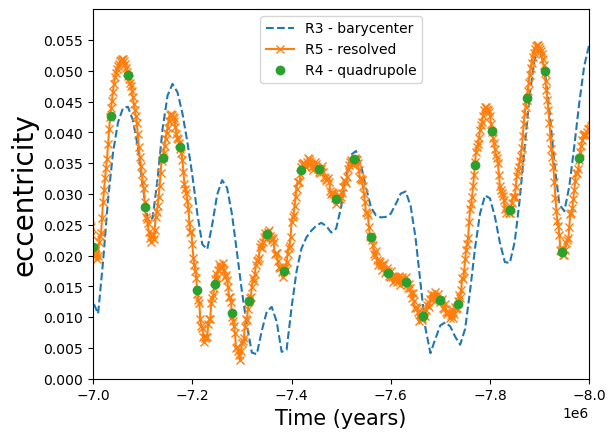

In [368]:
plt.plot(times, es, '--', label = 'R3 - barycenter')
plt.plot(times2, es2, 'x-', label='R5 - resolved')
# plt.plot(times4, es4, 'o', label='R4 - quadrupole')
plt.plot(times3, es3, 'o', label='R4 - quadrupole')

# plt.plot(times, es, '.')
plt.ylabel("eccentricity", fontsize=20)
# plt.xlim(-23.8*1e6, -24.1*1e6)
plt.xlim(-7*1e6, -8*1e6)
plt.ylim(0,0.06)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.yticks(np.arange(0,0.06,0.005))
# plt.xticks(-np.arange(7*1e6,8.1*1e6,1*1e5))
plt.legend()
plt.show()

# plt.plot(times, ps, '.')
# plt.ylabel("pomega", fontsize=24)
# plt.xlim(-23.8*1e6, -24.1*1e6)
# plt.show()

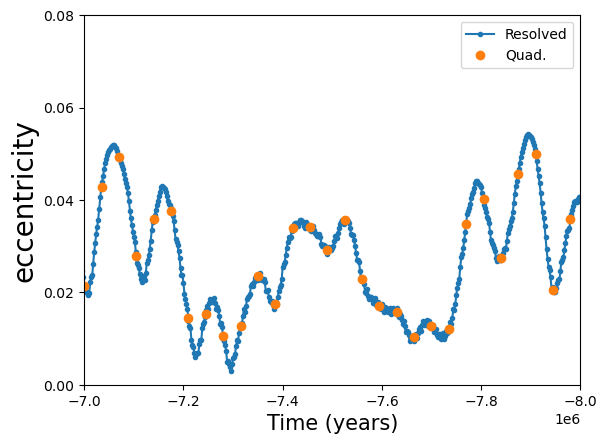

In [369]:
# plt.plot(times, es, '--', label = 'Barycenter')
plt.plot(times2, es2, '.-', label='Resolved')
plt.plot(times3, es3, 'o', label='Quad.')
plt.ylabel("eccentricity", fontsize=20)
# plt.xlim(-23.8*1e6, -24.1*1e6)
plt.xlim(-7*1e6, -8*1e6)
# plt.xlim(-0*1e6, -1*1e6)
plt.ylim(0,0.08)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.yticks(np.arange(0,0.081,0.02))
plt.legend()
plt.show()

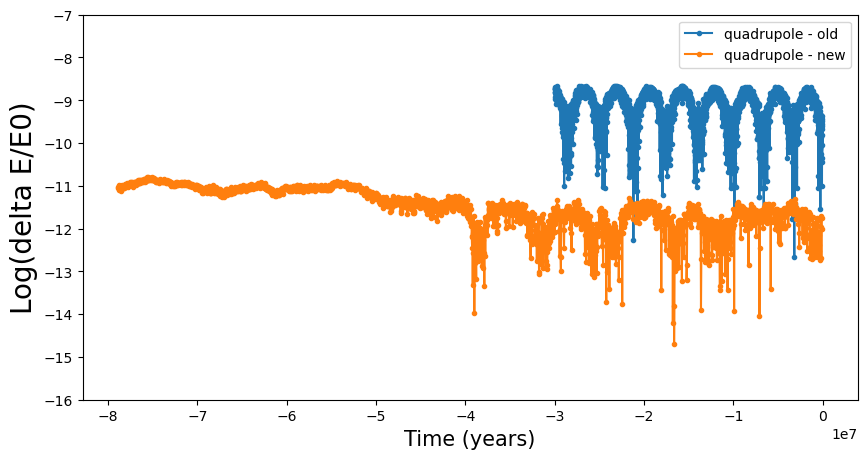

In [370]:
plt.figure(figsize=[10,5])
plt.plot(times4[2::], np.log10(np.abs((E4[2::]-E4[0])/E4[0])), '.-', label='quadrupole - old')
plt.plot(times3[2::], np.log10(np.abs((E3[2::]-E3[0])/E3[0])), '.-', label='quadrupole - new')
plt.ylim(-16,-7)
# plt.xlim(np.min(times3),np.max(times3))
plt.ylabel("Log(delta E/E0)", fontsize=20)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.legend()
plt.show()